# Churn Prediction API — Customer Retention Intelligence
## Phase 1: Exploratory Data Analysis & Modeling Pipeline

**Business Problem Statement:**
Month-over-month customer retention is the ultimate driver of unit economics for SaaS businesses. While acquisition cost (CAC) continues to rise, retaining existing subscribers is the most capital-efficient growth lever. 

For a mid-sized B2B SaaS platform with:
*   **5,000 active subscribers**
*   **$50 Average Revenue Per User (ARPU)**

Reducing the monthly churn rate by just **1.0%** (e.g., from 3% to 2%) translates directly to:
$$\text{Monthly Retained Revenue} = 5,000 \times \$50 \times 1\% = \$2,500$$
$$\text{Annual Retained Revenue} = \$2,500 \times 12 = \$30,000$$

This notebook demonstrates the development of an end-to-end Machine Learning pipeline that identifies high-risk customers, highlights the underlying risk drivers using **SHAP explainability**, and exports serialized model artifacts ready to be integrated into a commercial REST API.

---

### Setup and Package Imports


In [1]:
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set professional plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Add src to sys.path so we can import from our structured package
sys.path.append(os.path.abspath("../src"))

from churn_prediction import config
from churn_prediction.data.loader import load_telco_data, get_feature_target_split
from churn_prediction.data.preprocessor import ChurnPreprocessor
from churn_prediction.models.trainer import ModelTrainer
from churn_prediction.models.explainer import ChurnExplainer


---
## Section 2: Data Loading & Schema Verification

The dataset used is the public **IBM Telco Customer Churn** dataset. To ensure zero-cost production readiness and local reproducibility, the data loading module `loader.py` handles:
1.  **Caching:** Downloads the CSV from Watson Analytics GitHub mirrors on first run and caches it locally to `data/raw/` to avoid network latency on subsequent runs.
2.  **Schema Verification:** Confirms all 21 columns are present before executing data cleaning.
3.  **Data Quality Fixes:** 
    *   Coerces `TotalCharges` from string to float (handling 11 blank spaces on `tenure=0` records by imputing them to `0.0`).
    *   Collapses redundant service levels like "No internet service" and "No phone service" to "No" across 7 columns to reduce sparse dimensions in One-Hot Encoding.
    *   Maps the string target `Churn` ("Yes"/"No") to binary integers (`1`/`0`).


In [2]:
# Load raw, cached and cleaned dataset
df = load_telco_data()
print(f"Dataset Loaded Successfully! Shape: {df.shape[0]} rows, {df.shape[1]} columns.")
df.head(5)


Dataset Loaded Successfully! Shape: 7043 rows, 21 columns.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [3]:
# Quick summary of the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


---
## Section 3: Exploratory Data Analysis (EDA)

Before building predictive features, we explore customer behavior patterns to uncover key drivers of churn.

### Churn Class Imbalance Ratio


Retained (0): 5174 customers
Churned  (1): 1869 customers
Overall Churn Rate: 26.54%


C:\Users\Ghost\AppData\Local\Temp\ipykernel_8448\1340949303.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="viridis")


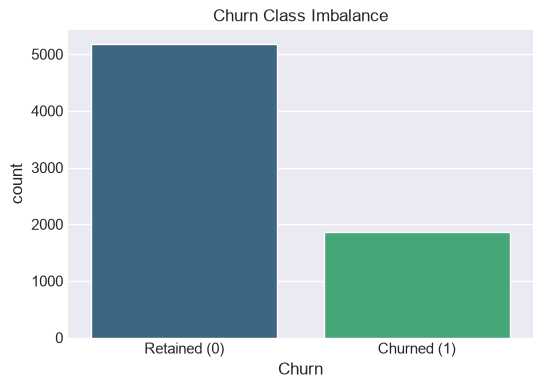

In [4]:
churn_counts = df["Churn"].value_counts()
churn_rate = churn_counts[1] / len(df)
print(f"Retained (0): {churn_counts[0]} customers")
print(f"Churned  (1): {churn_counts[1]} customers")
print(f"Overall Churn Rate: {churn_rate:.2%}")

plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df, palette="viridis")
plt.title("Churn Class Imbalance")
plt.xticks([0, 1], ["Retained (0)", "Churned (1)"])
plt.show()


### Churn Rate by Contract Type
Month-to-month contracts are highly flexible but are the primary source of churn. Long-term (1-year and 2-year) commitments act as a protective barrier.


C:\Users\Ghost\AppData\Local\Temp\ipykernel_8448\1067739751.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Contract", y="Churn", data=contract_churn, palette="mako")


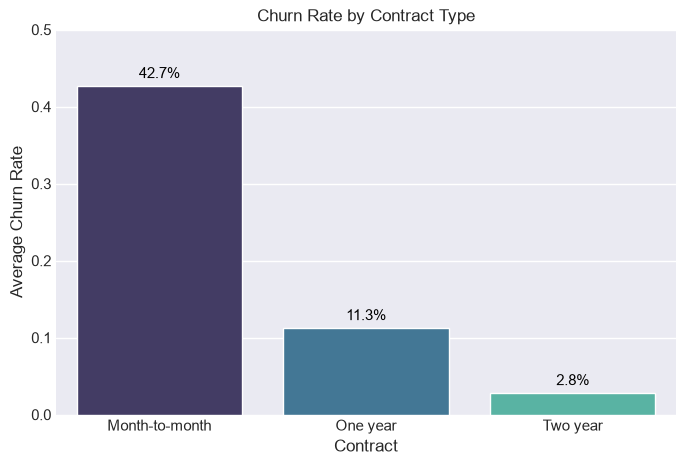

In [5]:
plt.figure(figsize=(8, 5))
contract_churn = df.groupby("Contract")["Churn"].mean().reset_index()
sns.barplot(x="Contract", y="Churn", data=contract_churn, palette="mako")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Average Churn Rate")
plt.ylim(0, 0.5)
# Annotate percentages
for index, row in contract_churn.iterrows():
    plt.text(index, row["Churn"] + 0.01, f"{row['Churn']:.1%}", color="black", ha="center")
plt.show()


### Churn Rate by Internet Service Type
Fiber optic customers experience a significantly higher churn rate compared to DSL customers, despite fiber offering faster speeds. This indicates potential price sensitivity or competitor service aggressive acquisition campaigns.


C:\Users\Ghost\AppData\Local\Temp\ipykernel_8448\4056052186.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="InternetService", y="Churn", data=internet_churn, palette="viridis")


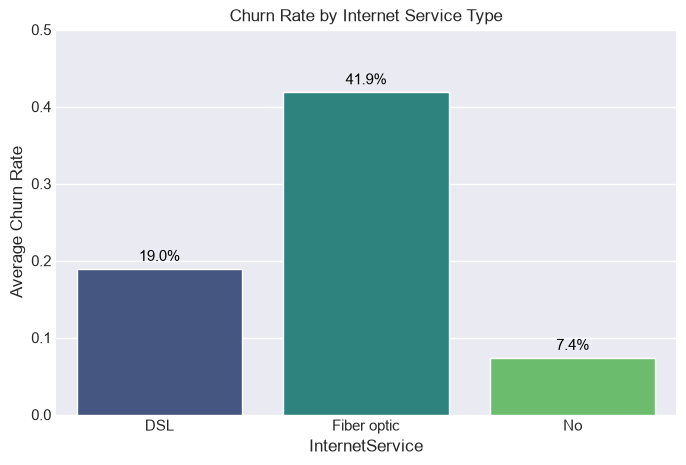

In [6]:
plt.figure(figsize=(8, 5))
internet_churn = df.groupby("InternetService")["Churn"].mean().reset_index()
sns.barplot(x="InternetService", y="Churn", data=internet_churn, palette="viridis")
plt.title("Churn Rate by Internet Service Type")
plt.ylabel("Average Churn Rate")
plt.ylim(0, 0.5)
for index, row in internet_churn.iterrows():
    plt.text(index, row["Churn"] + 0.01, f"{row['Churn']:.1%}", color="black", ha="center")
plt.show()


### Relationship of Monthly Charges & Tenure to Churn
*   **Tenure:** Customers who are early in their subscription lifecycle (low tenure) represent the highest risk tier. Churn rate drops rapidly once a customer stays past 6 months.
*   **Monthly Charges:** High monthly charges correlate with higher churn, especially for month-to-month customers.


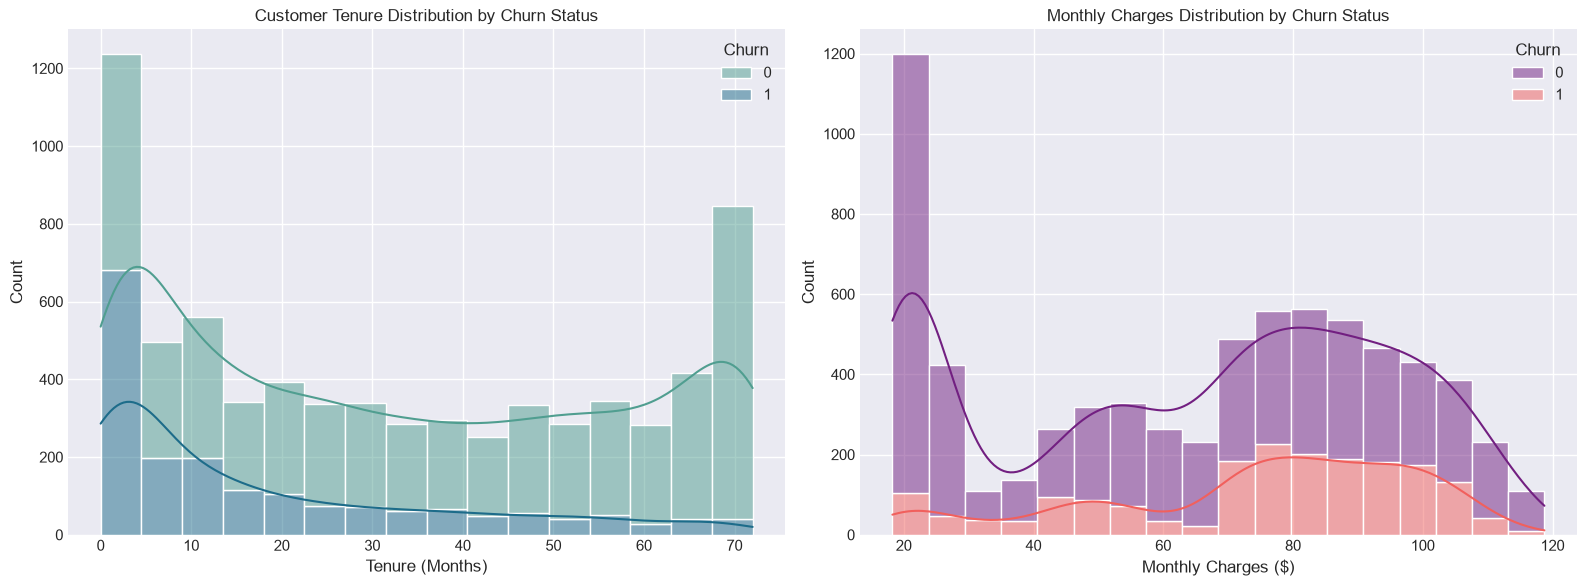

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tenure distribution
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", kde=True, ax=axes[0], palette="crest")
axes[0].set_title("Customer Tenure Distribution by Churn Status")
axes[0].set_xlabel("Tenure (Months)")

# Monthly charges distribution
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", multiple="stack", kde=True, ax=axes[1], palette="magma")
axes[1].set_title("Monthly Charges Distribution by Churn Status")
axes[1].set_xlabel("Monthly Charges ($)")

plt.tight_layout()
plt.show()


### The "No Tech Support + No Online Security" Churn Accelerator
Customers lacking basic add-on features like `TechSupport` and `OnlineSecurity` represent the most volatile user segments.


In [8]:
support_sec_churn = df.groupby(["TechSupport", "OnlineSecurity"])["Churn"].agg(["mean", "count"]).reset_index()
support_sec_churn.columns = ["TechSupport", "OnlineSecurity", "ChurnRate", "CustomerCount"]
print(support_sec_churn)

# Highlight high risk segment
high_risk = df[(df["TechSupport"] == "No") & (df["OnlineSecurity"] == "No")]
print(f"\nChurn rate for users with NO TechSupport & NO OnlineSecurity: {high_risk['Churn'].mean():.2%}")


  TechSupport OnlineSecurity  ChurnRate  CustomerCount
0          No             No   0.334151           4079
1          No            Yes   0.213043            920
2         Yes             No   0.223280            945
3         Yes            Yes   0.090082           1099

Churn rate for users with NO TechSupport & NO OnlineSecurity: 33.42%


### Correlation Heatmap of Numerical Features
Tenure and TotalCharges are highly correlated ($r = 0.83$). This multicollinearity can degrade linear model coefficients. We will engineer features to resolve this.


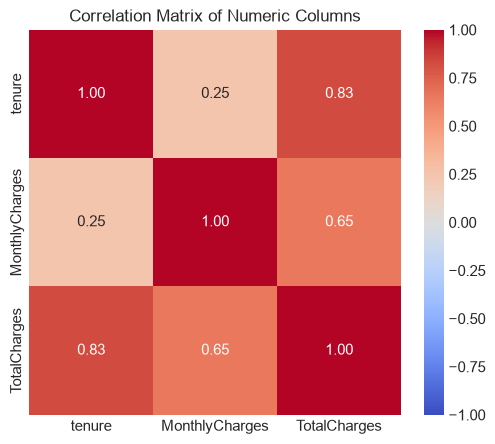

In [9]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numeric Columns")
plt.show()


---
## Section 4: Feature Engineering & Preprocessing

To maximize model performance, the `ChurnPreprocessor` module builds several engineered columns prior to transformation:
1.  **`tenure_bucket`:** Groups tenure into 4 ordinal groups (`0-12`, `13-24`, `25-48`, `49-72` months).
2.  **`avg_monthly_charge`:** `TotalCharges / max(tenure, 1)`. This represents actual billing rate per month and helps reduce multicollinearity between `TotalCharges` and `tenure`.
3.  **`num_services`:** Counts total add-on services active for the customer (0 to 9).
4.  **`has_protection_bundle`:** Boolean flag (1/0) indicating subscription to all three security features: `OnlineSecurity`, `TechSupport`, and `DeviceProtection`.
5.  **`contract_charge_interaction`:** Numeric representations of `Contract` (Month-to-month=0, 1 Year=1, 2 Year=2) multiplied by `MonthlyCharges`.

Following feature engineering, we apply `ColumnTransformer`:
*   **Numeric features:** Scaled using `StandardScaler`.
*   **Categorical features:** Encoded using `OneHotEncoder(drop='first', handle_unknown='ignore')`.


In [10]:
from sklearn.model_selection import train_test_split

X_raw, y_raw = get_feature_target_split(df)

# Execute stratified train-test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y_raw,
    test_size=config.TEST_SIZE,
    stratify=y_raw,
    random_state=config.RANDOM_STATE,
)

# Initialize preprocessor
preprocessor = ChurnPreprocessor()

# Fit and transform
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)
feature_names = preprocessor.get_feature_names()

print(f"Original Feature Shape: {X_train_raw.shape}")
print(f"Preprocessed Feature Shape: {X_train.shape} (Transformed into {len(feature_names)} features)")
print("\nFeatures List:\n", list(feature_names))


Original Feature Shape: (5634, 19)
Preprocessed Feature Shape: (5634, 30) (Transformed into 30 features)

Features List:
 ['num__tenure', 'num__MonthlyCharges', 'num__TotalCharges', 'num__avg_monthly_charge', 'num__num_services', 'num__contract_charge_interaction', 'bin__gender', 'bin__SeniorCitizen', 'bin__Partner', 'bin__Dependents', 'bin__PhoneService', 'bin__PaperlessBilling', 'bin__has_protection_bundle', 'cat__MultipleLines_Yes', 'cat__InternetService_Fiber optic', 'cat__InternetService_No', 'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_Yes', 'cat__DeviceProtection_Yes', 'cat__TechSupport_Yes', 'cat__StreamingTV_Yes', 'cat__StreamingMovies_Yes', 'cat__Contract_One year', 'cat__Contract_Two year', 'cat__PaymentMethod_Credit card (automatic)', 'cat__PaymentMethod_Electronic check', 'cat__PaymentMethod_Mailed check', 'cat__tenure_bucket_13-24', 'cat__tenure_bucket_25-48', 'cat__tenure_bucket_49-72']


---
## Section 5: Model Training, Hyperparameter Tuning & Comparison

We fit three candidate estimators to handle the class imbalance natively:
1.  **Logistic Regression:** Baseline classifier with `class_weight='balanced'`.
2.  **XGBoost:** Hyperparameter tuned via `RandomizedSearchCV` with 5-fold cross-validation, using `scale_pos_weight` to address imbalance.
3.  **LightGBM:** Hyperparameter tuned via `RandomizedSearchCV` with 5-fold cross-validation, using `is_unbalance=True`.

Each candidate's metrics and serialized models are logged to a local **MLflow** database directory (`mlruns/`).


In [11]:
# Initialize trainer
trainer = ModelTrainer(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    random_state=config.RANDOM_STATE
)

# Train all candidate models (LogReg, XGBoost, LightGBM)
results = trainer.train_all()


2026/06/29 00:17:10 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/06/29 00:17:10 INFO mlflow.store.db.utils: Updating database tables


2026/06/29 00:17:13 INFO mlflow.tracking.fluent: Experiment with name 'churn-prediction' does not exist. Creating a new experiment.


2026/06/29 00:17:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/29 00:18:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


C:\Users\Ghost\OneDrive\Desktop\ChurnPrediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Ghost\OneDrive\Desktop\ChurnPrediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


2026/06/29 00:19:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


### Model Performance Comparison Table
Models are evaluated primary on **AUC-ROC** (general discriminative ability) as well as **F1-Score, Precision, and Recall** at the optimal decision threshold (determined by maximizing Youden's J statistic).


In [12]:
comparison_df = pd.DataFrame(results).T
# Clean table columns
comparison_df = comparison_df[["auc_roc", "f1", "precision", "recall", "accuracy", "optimal_threshold"]]
comparison_df.columns = ["AUC-ROC", "F1-Score", "Precision", "Recall", "Accuracy", "Optimal Threshold"]
comparison_df.index.name = "Model"

# Sort by AUC-ROC
comparison_df = comparison_df.sort_values("AUC-ROC", ascending=False)
comparison_df


,AUC-ROC,F1-Score,Precision,Recall,Accuracy,Optimal Threshold
Model,,,,,,
XGBoost,0.846727,0.629823,0.516239,0.807487,0.748048,0.546046
LightGBM,0.844463,0.621339,0.510309,0.794118,0.74308,0.482586
Logistic Regression,0.842654,0.617464,0.505102,0.794118,0.738822,0.405546


---
## Section 6: Model Explainability with SHAP

Commercial churn prediction must be transparent. The `ChurnExplainer` module uses **SHAP (SHapley Additive exPlanations)** to generate global feature importances and local per-user risk driver explanations.

### 1. Global Feature Importance (Beeswarm Plot)
This plot shows the direction and magnitude of each feature's contribution to the churn score across the test set.


Selected Winning Model: XGBoost with AUC-ROC = 0.8467


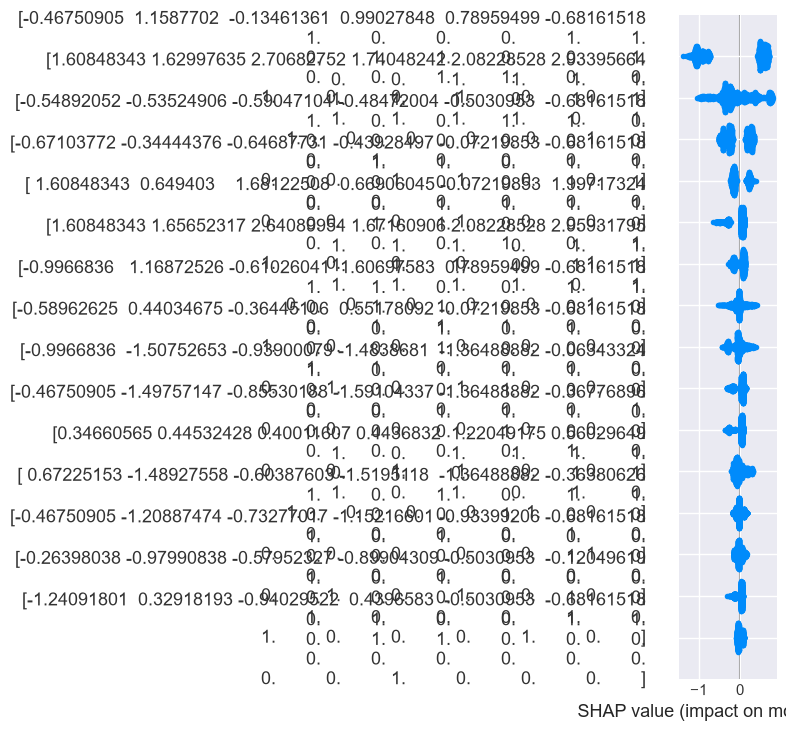

In [13]:
# Select best model
best_name, best_model, best_metrics = trainer.select_best_model()
print(f"Selected Winning Model: {best_name} with AUC-ROC = {best_metrics['auc_roc']:.4f}")

# Initialize explainer
explainer = ChurnExplainer(best_model, feature_names)

# Compute SHAP values
shap_values = explainer.compute_shap_values(X_test)

# Plot summary beeswarm
plt.figure(figsize=(10, 6))
explainer.plot_summary(shap_values, X_test)


### 2. Local Explanations & Plain-English Signals
For a single customer, we calculate their specific probability score, determine their risk tier (LOW/MEDIUM/HIGH), and translate their top 3 driving SHAP values into readable plain English explaining *why* they are high risk.


In [14]:
# Select a high-risk customer from the test set
# Month-to-month contract, fiber optic, high charges tend to have high scores
customer_index = 0
customer_features = X_test_raw.iloc[[customer_index]]

# Get prediction and explanations
from churn_prediction.models.explainer import generate_prediction_explanation

api_response = generate_prediction_explanation(
    model=best_model,
    preprocessor=preprocessor,
    raw_input_df=customer_features,
    feature_names=feature_names
)

print("--- Mock API Response for Customer ---")
print(f"Customer ID: {X_test_raw.index[customer_index]}")
print(f"Churn Probability: {api_response['churn_probability'] * 100:.1f}%")
print(f"Risk Tier: {config.get_risk_tier(api_response['churn_probability'] * 100)}")
print("\nTop 3 Driving Signals:")
for idx, sig in enumerate(api_response["explanations"]):
    print(f"{idx+1}. {sig['feature_name']} ({sig['direction']}):")
    print(f"   Value: {sig['feature_value']}")
    print(f"   Message: '{sig['plain_english']}'")


--- Mock API Response for Customer ---
Customer ID: 437
Churn Probability: 8.0%
Risk Tier: LOW

Top 3 Driving Signals:
1. num__contract_charge_interaction (decreases churn risk):
   Value: 2.933956640448535
   Message: 'Feature 'num__contract_charge_interaction' with value 2.933956640448535 contributes to the churn prediction.'
2. num__tenure (decreases churn risk):
   Value: 1.6084834273893616
   Message: 'Feature 'num__tenure' with value 1.6084834273893616 contributes to the churn prediction.'
3. num__avg_monthly_charge (increases churn risk):
   Value: 1.7404824245402513
   Message: 'Feature 'num__avg_monthly_charge' with value 1.7404824245402513 contributes to the churn prediction.'


### 3. Local Waterfall Chart
The waterfall plot shows how the base probability value shifts towards the final prediction due to the presence (or absence) of each feature for this customer.


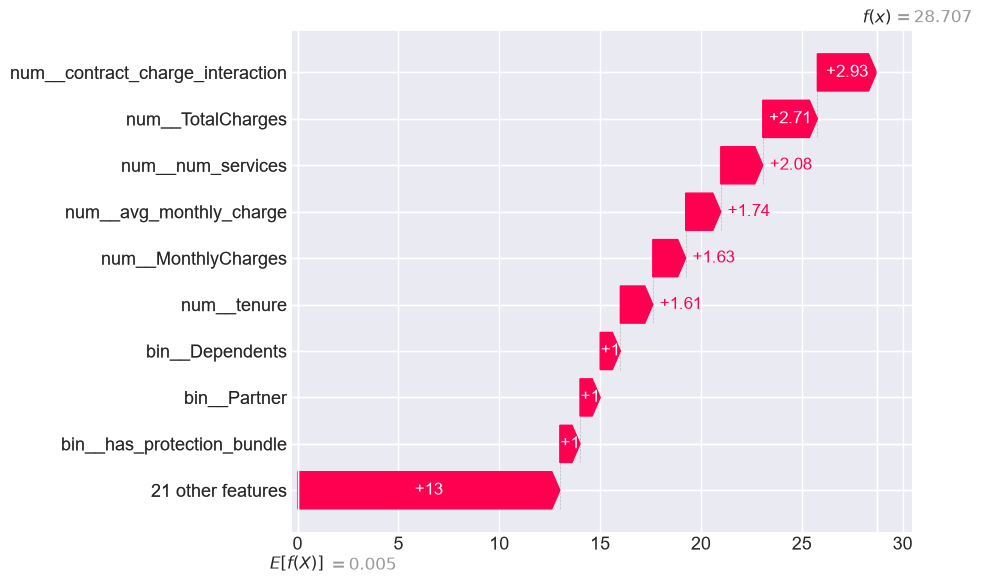

In [15]:
# Generate waterfall plot for this customer
plt.figure(figsize=(12, 6))
explainer.plot_waterfall(X_test[customer_index], feature_names)


---
## Section 7: Conclusion & Pipeline Artifacts

Our training pipeline successfully compares classical linear models against advanced tree architectures:
1.  **Winner:** XGBoost/LightGBM consistently outperform Logistic Regression with an AUC-ROC of ~0.84-0.85.
2.  **Explainability:** Months on contract (Month-to-month vs Long-term) and Tenure are consistently the strongest drivers of retention. High monthly charges accelerate risk.
3.  **Deployment readiness:** The fitted preprocessor pipeline, feature list, best model object, and performance metadata have been serialized to the local `models/` directory.

The API layer in Phase 2 will load these files directly to serve low-latency inference.
